In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
s3_path = 's3://sagemaker-eu-north-1-910119346557/training-data/newsCorpora.csv'

In [3]:
df = pd.read_csv(s3_path,sep='\t',names=['ID','TITLE','URL','PUBLISHER','CATEGORY','STORY','HOSTNAME','TIMESTAMP'])

TypeError: object NoneType can't be used in 'await' expression

In [4]:
df.head()

,ID,TITLE,URL,PUBLISHER,CATEGORY,STORY,HOSTNAME,TIMESTAMP
0,1,"Fed official says weak data caused by weather,...",http://www.latimes.com/business/money/la-fi-mo...,Los Angeles Times,b,ddUyU0VZz0BRneMioxUPQVP6sIxvM,www.latimes.com,1394470370698
1,2,Fed's Charles Plosser sees high bar for change...,http://www.livemint.com/Politics/H2EvwJSK2VE6O...,Livemint,b,ddUyU0VZz0BRneMioxUPQVP6sIxvM,www.livemint.com,1394470371207
2,3,US open: Stocks fall after Fed official hints ...,http://www.ifamagazine.com/news/us-open-stocks...,IFA Magazine,b,ddUyU0VZz0BRneMioxUPQVP6sIxvM,www.ifamagazine.com,1394470371550
3,4,"Fed risks falling 'behind the curve', Charles ...",http://www.ifamagazine.com/news/fed-risks-fall...,IFA Magazine,b,ddUyU0VZz0BRneMioxUPQVP6sIxvM,www.ifamagazine.com,1394470371793
4,5,Fed's Plosser: Nasty Weather Has Curbed Job Gr...,http://www.moneynews.com/Economy/federal-reser...,Moneynews,b,ddUyU0VZz0BRneMioxUPQVP6sIxvM,www.moneynews.com,1394470372027


In [5]:
df = df[['TITLE','CATEGORY']]

In [6]:
my_dict = {'b':'Business',
           'e':'Entertainment',
           'm':'Health',
           't': 'Technology'
}
           

In [7]:
def update_catgory(x: str) -> str:
    return my_dict[x]

In [8]:
df['CATEGORY'] = df['CATEGORY'].apply(lambda x: update_catgory(x))

In [9]:
df.head()

,TITLE,CATEGORY
0,"Fed official says weak data caused by weather,...",Business
1,Fed's Charles Plosser sees high bar for change...,Business
2,US open: Stocks fall after Fed official hints ...,Business
3,"Fed risks falling 'behind the curve', Charles ...",Business
4,Fed's Plosser: Nasty Weather Has Curbed Job Gr...,Business


In [18]:
category_counts = df['CATEGORY'].value_counts()
category_counts

CATEGORY
Entertainment    152469
Business         115967
Technology       108344
Health            45639
Name: count, dtype: int64

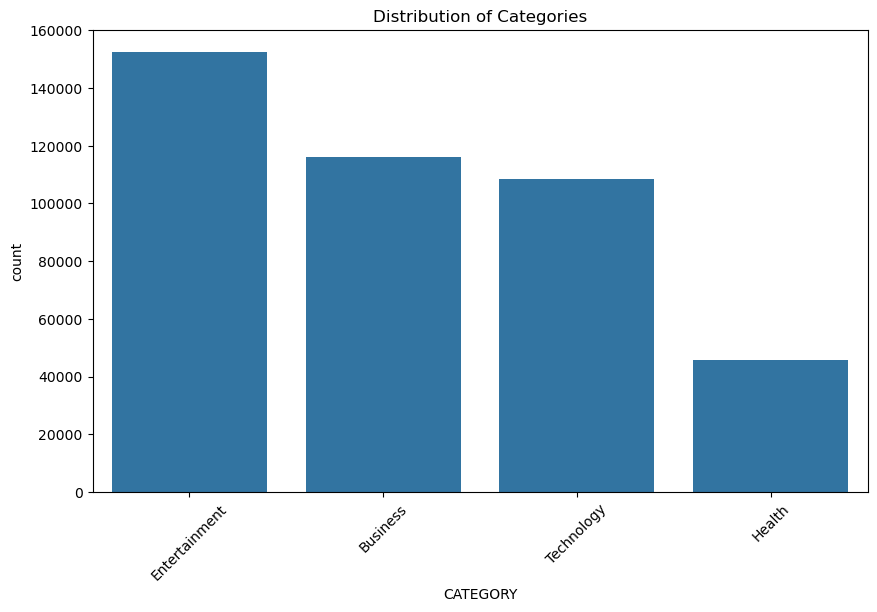

In [19]:
plt.figure(figsize=(10,6))
sns.countplot(data=df,x='CATEGORY',order=category_counts.index)
plt.title('Distribution of Categories')
plt.xticks(rotation=45)
plt.show()

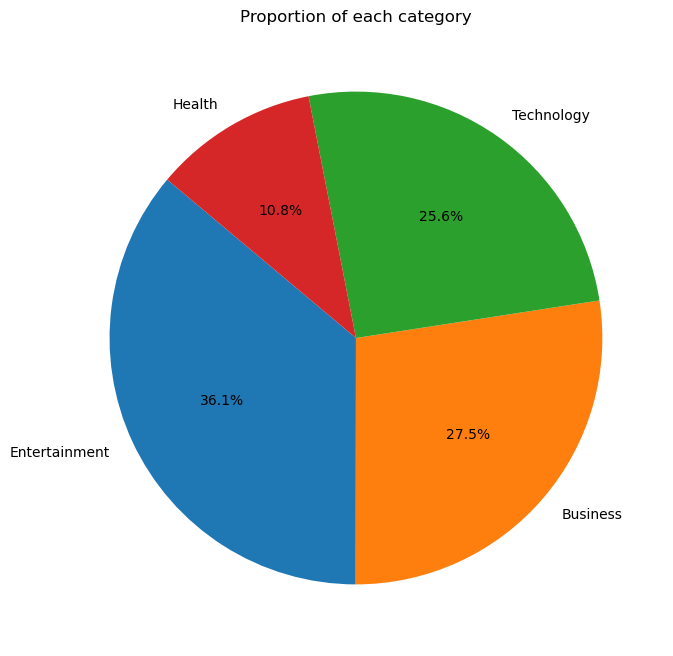

In [22]:
plt.figure(figsize=(8,8))
plt.pie(category_counts,labels=category_counts.index,autopct='%1.1f%%',startangle=140)
plt.title('Proportion of each category')
plt.show()

In [29]:
df['TITLE_LENGTH'] = df['TITLE'].map(lambda x: len(x.split()))

In [30]:
df.head()

,TITLE,CATEGORY,TITLE_LENGTH
0,"Fed official says weak data caused by weather,...",Business,12
1,Fed's Charles Plosser sees high bar for change...,Business,12
2,US open: Stocks fall after Fed official hints ...,Business,11
3,"Fed risks falling 'behind the curve', Charles ...",Business,9
4,Fed's Plosser: Nasty Weather Has Curbed Job Gr...,Business,8


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 422419 entries, 0 to 422418
Data columns (total 3 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   TITLE         422419 non-null  object
 1   CATEGORY      422419 non-null  object
 2   TITLE_LENGTH  422419 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 9.7+ MB


In [37]:
df[df['TITLE_LENGTH'] > 20]['TITLE'].iloc[0]

'Love & Hip-Hop\' Star Benzino Shot By Nephew En Route To Mother\'s Funeral\thttp://www.designntrend.com/articles/12221/20140330/love-hip-hop-star-benzino-shot-nephew-en-route-mothers.htm\tDesign \\& Trend\te\tdMXJCPWNIRd9VWMrvxGgoEIc8UaMM\twww.designntrend.com\t1396236920861\n69475\t\'Love & Hip Hop: Atlanta\' cast member Benzino shot, wounded\thttp://www.dailyfreeman.com/general-news/20140330/love-hip-hop-atlanta-cast-member-benzino-shot-wounded\tKingston Daily Freeman\te\tdMXJCPWNIRd9VWMrvxGgoEIc8UaMM\twww.dailyfreeman.com\t1396236921087\n69476\tRapper Benzino shot during mother\'s funeral procession\thttp://myfox8.com/2014/03/30/rapper-benzino-shot-during-mothers-funeral-procession/\tmyfox8.com\te\tdMXJCPWNIRd9VWMrvxGgoEIc8UaMM\tmyfox8.com\t1396236921313\n69477\tLove & Hip Hop Atlanta\'s Benzino Shot At Mother\'s Funeral By His Nephew  ...\thttp://www.memphisrap.com/2014/03/30/love-hip-hop-atlantas-benzino-shot-at-mothers-funeral-by-his-nephew-photos-details/\tMemphisRap.com\te\tdM